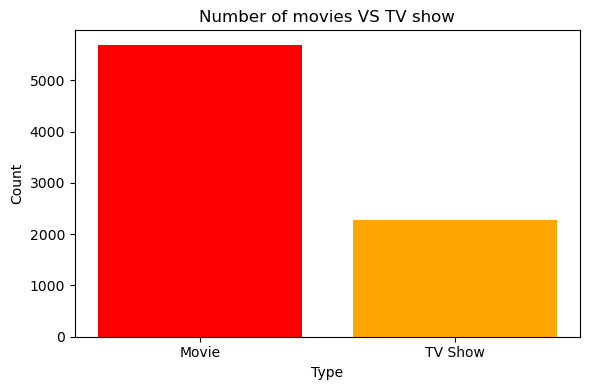

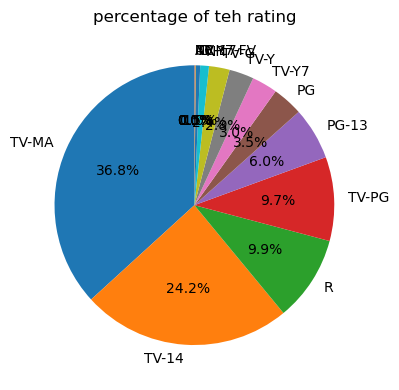

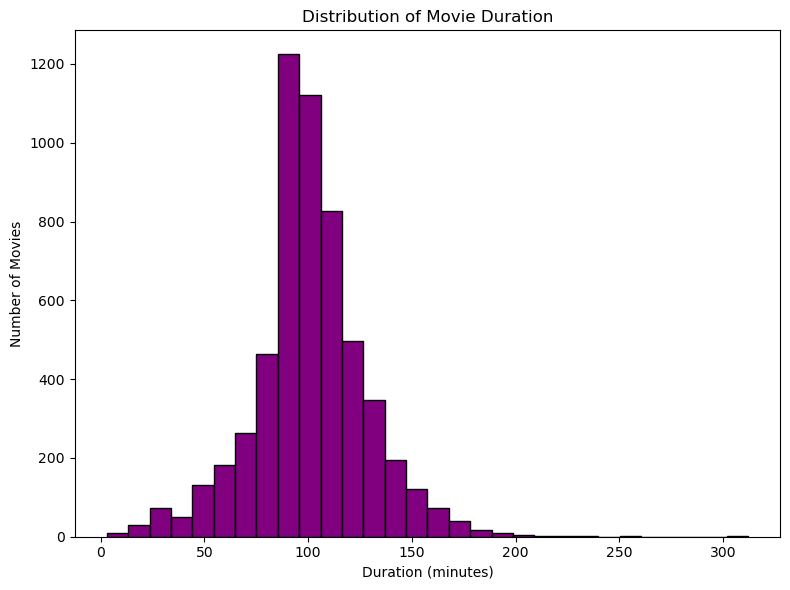

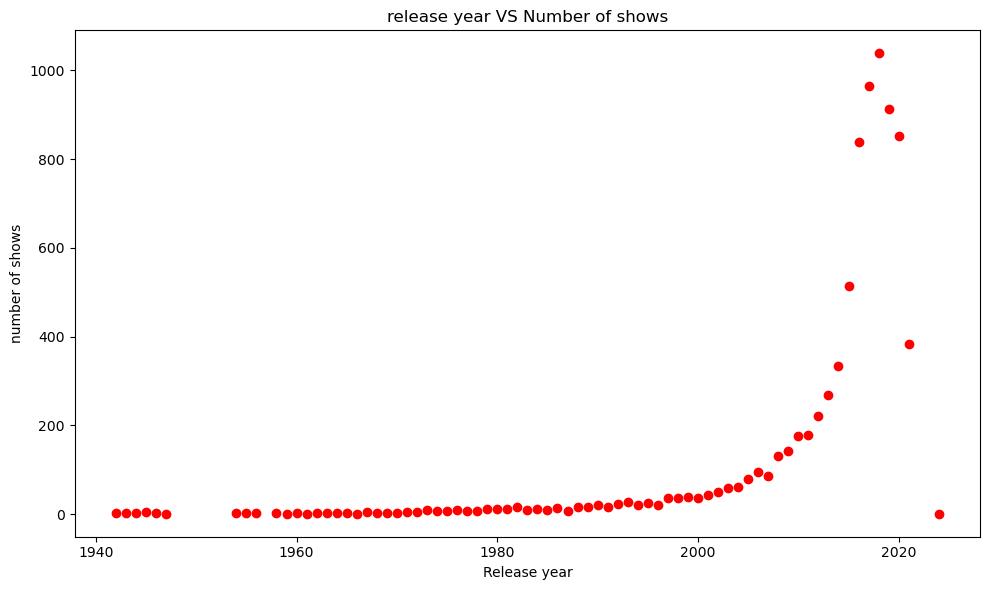

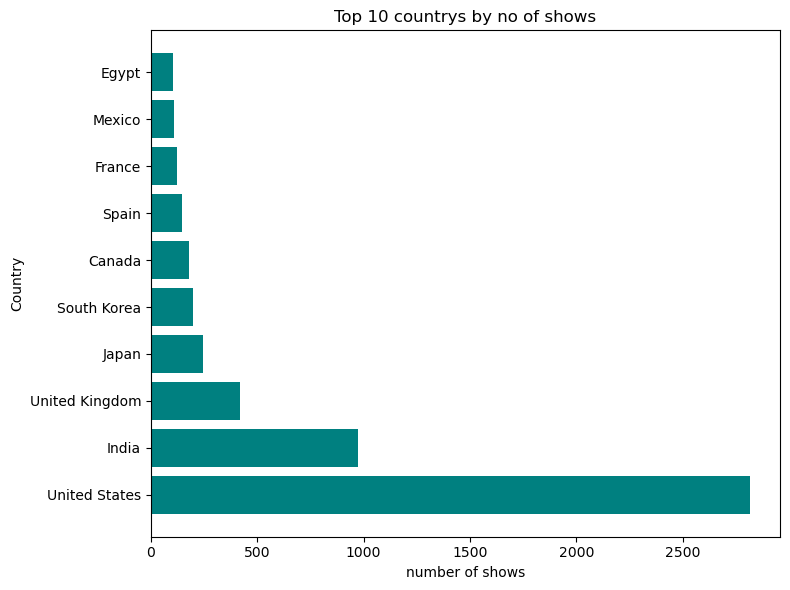

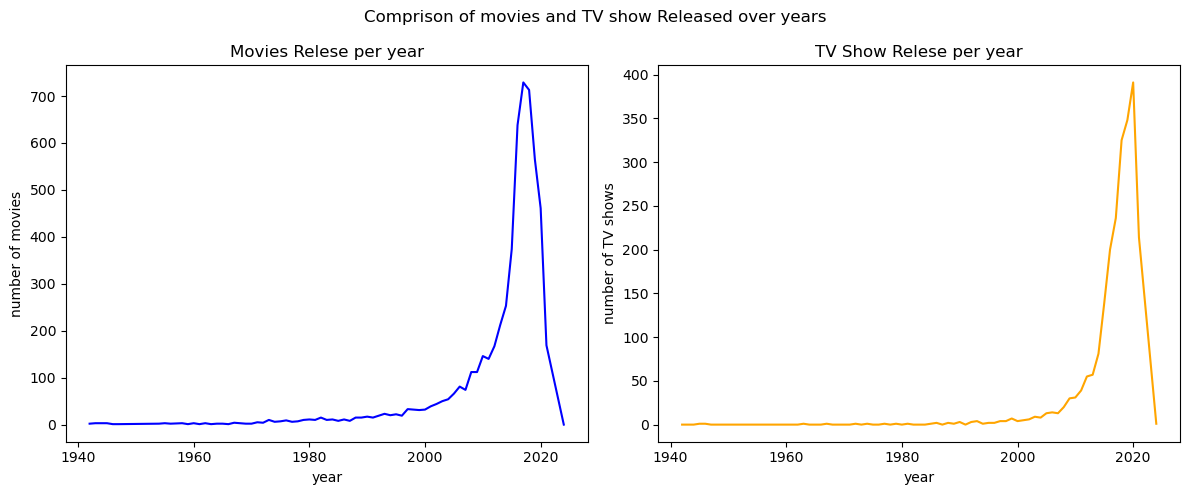

In [35]:
#importing the libraries
import pandas as pd
import matplotlib.pyplot as plt

#load the data
df=pd.read_csv('netflix_titles.csv',encoding='latin1')

#data clean
df=df.dropna(subset=['type','release_year','rating', 'country','duration'])

#bar chart
type_count=df['type'].value_counts()
plt.figure(figsize=(6,4))
plt.bar(type_count.index,type_count.values,color=['red','orange'])
plt.title('Number of movies VS TV show')
plt.xlabel('Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('movies_vs_tvshow.png')
plt.show()

#pie chart
rating_counts=df['rating'].value_counts()
plt.figure(figsize=(6,4))
plt.pie(rating_counts,labels=rating_counts.index,autopct='%1.1f%%',startangle=90)
plt.title('percentage of teh rating')
plt.tight_layout()
plt.savefig('content_rating_pie.png')
plt.show()

# Histogram of movies
movie_df = df[df['type'] == 'Movie'].copy()

movie_df['duration_int'] = movie_df['duration'].str.replace('min', '').astype(int)

plt.figure(figsize=(8, 6))
plt.hist(movie_df['duration_int'], bins=30, color='purple', edgecolor='black')
plt.title('Distribution of Movie Duration')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')
plt.tight_layout()
plt.savefig('movies_duration_histogram.png')
plt.show()

#scatter plot
release_counts=df['release_year'].value_counts().sort_index()
plt.figure(figsize=(10,6))
plt.scatter(release_counts.index,release_counts.values,color='red')
plt.title('release year VS Number of shows')
plt.xlabel('Release year')
plt.ylabel('number of shows')
plt.tight_layout()
plt.savefig('Release_year_scatter.png')
plt.show()

#bar horizontal
country_counts=df['country'].value_counts().head(10)
plt.figure(figsize=(8,6))
plt.barh(country_counts.index,country_counts.values,color='teal')
plt.title('Top 10 countrys by no of shows')
plt.xlabel('number of shows')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('top10_countries.png')
plt.show()

content_by_year = df.groupby(['release_year','type']).size().unstack().fillna(0)

fig,ax=plt.subplots(1,2,figsize=(12,5))

#first subplot:movies
ax[0].plot(content_by_year.index,content_by_year['Movie'],color='blue')
ax[0].set_title('Movies Relese per year')
ax[0].set_xlabel('year')
ax[0].set_ylabel('number of movies')

#Second subplot:TV show
ax[1].plot(content_by_year.index,content_by_year['TV Show'],color='orange')
ax[1].set_title('TV Show Relese per year')
ax[1].set_xlabel('year')
ax[1].set_ylabel('number of TV shows')

fig.suptitle('Comprison of movies and TV show Released over years')

plt.tight_layout()
plt.savefig('movies_tv_show_comparison.png')
plt.show()